# Adaptive histogram-based features for pomegranate fruit & leaf diseases — feature-extraction reproduction

**Paper:** P. Kadam et al., *Domain-independent adaptive histogram-based features for pomegranate fruit and leaf diseases classification*, CAAI Transactions on Intelligence Technology 10(2):317–336 (version of record, online 2024-11-12), DOI: [10.1049/cit2.12390](https://doi.org/10.1049/cit2.12390) (CC BY 4.0).

**Author code:** `prajwalkumarprof/Domain-Independent-Adaptive-Histogram-Based-Approach-`, pinned commit `5530ba9cd22b383d95ad5417b4b2a67a51f642ad` (no README/LICENSE in the repository).

**Scope (partial demonstration):** the paper's feature-extraction subsection only. For each pomegranate image we compute 256-bin histograms of the normalized grey, R, G and B channels, then the **Chi-Square distance** of each colour histogram to the grey histogram (grey = average of R, G, B, used as reference), plus the **half-split (P1/P2)** variants and histogram peak values — exactly the features produced by the author's `Ap_Chi_ALLFeatures.py`. The ANN/CNN classification stage is **not** reproduced: the repository contains no trained weights and its Keras scripts target a different (raw-image CNN, CIFAR-style paths) design.

**実行内容(日本語):** 本ノートブックは論文の特徴量抽出部分のみを再現します。ざん果・葉画像からグレー/R/G/B の 256 ビン・ヒストグラムを作り、グレーを基準としたカイ二乗距離(全体と半分割 P1/P2)およびピーク値を著者コード `Ap_Chi_ALLFeatures.py` に従って計算します。分類(ANN)は重みが存在しないため対象外です。

## 1. Runtime selection — CPU only / 実行環境: CPU

This demonstration is pure histogram arithmetic on nine small JPEGs (< 150 KB total) with NumPy/OpenCV/Matplotlib. It needs **no GPU**; select **Runtime → Change runtime type → CPU** (the default) and *Runtime → Run all*. Expected wall time: a few minutes, dominated by the one-time repository download (~0.2 MB).

**実行環境の選択:** GPU は不要です。CPU ランタイムのままで「ランタイム → すべてのセルを実行」してください。数分で完了します。

### Cell — Environment check
Verify the scientific stack that this notebook relies on (all preinstalled on Colab; nothing is downgraded or pinned to obsolete versions). Prints library versions used by this run.

**このセルの内容:** NumPy / OpenCV / Matplotlib / Pillow / pandas / openpyxl のバージョンを確認します(いずれも Colab に標準搭載)。

In [ ]:
import sys
import numpy, cv2, matplotlib, PIL, pandas, openpyxl
print("python      :", sys.version.split()[0])
print("numpy       :", numpy.__version__)
print("opencv      :", cv2.__version__)
print("matplotlib  :", matplotlib.__version__)
print("pillow      :", PIL.__version__)
print("pandas      :", pandas.__version__)
print("openpyxl    :", openpyxl.__version__)

python      : 3.13.16
numpy       : 2.1.3
opencv      : 5.0.0
matplotlib  : 3.10.0
pillow      : 11.3.0
pandas      : 2.2.3
openpyxl    : 3.1.5


### Cell — Acquire the pinned author inputs (Colab VM only)
Sparse partial clone of the author repository, pinned to the verified commit `5530ba9cd22b383d95ad5417b4b2a67a51f642ad`, retrieving **only** `test/` (the nine class-organized test JPEGs used by the feature scripts) and the paper supplement `features of Histo.xlsx`. A blobless clone (`--filter=blob:none --no-checkout`) fetches only commit/tree metadata first; a cone-mode sparse checkout then materializes the `test/` image tree plus the root-level supplement workbook. All bytes stay under `/content` on the Colab VM.

**このセルの内容:** 著者リポジトリをコミット `5530ba9…` に固定した部分クローン(blob なし)で取得し、`test/` の 9 枚の JPEG と補足資料 `features of Histo.xlsx` だけを `/content` 以下に展開します。

In [ ]:
import os, subprocess
REPO_URL = "https://github.com/prajwalkumarprof/Domain-Independent-Adaptive-Histogram-Based-Approach-.git"
COMMIT = "5530ba9cd22b383d95ad5417b4b2a67a51f642ad"
REPO_DIR = "/content/pomegranate-histo"
ENV = {**os.environ, "GIT_LFS_SKIP_SMUDGE": "1", "GIT_TERMINAL_PROMPT": "0"}
def git(*args):
    subprocess.run(["git", *args], check=True, cwd=REPO_DIR, env=ENV,
                   capture_output=True, text=True)
if not os.path.isdir(os.path.join(REPO_DIR, ".git")):
    subprocess.run(["git", "clone", "--filter=blob:none", "--no-checkout", REPO_URL, REPO_DIR],
                   check=True, capture_output=True, text=True, env=ENV)
git("sparse-checkout", "init", "--cone")
git("sparse-checkout", "set", "test")
git("fetch", "--depth", "1", "origin", COMMIT)
git("checkout", "--detach", "FETCH_HEAD")
head = subprocess.run(["git", "rev-parse", "HEAD"], check=True, cwd=REPO_DIR,
                      capture_output=True, text=True).stdout.strip()
assert head == COMMIT, f"checked-out commit {head} != pinned {COMMIT}"
print("checked out pinned commit:", head)

checked out pinned commit: 5530ba9cd22b383d95ad5417b4b2a67a51f642ad


### Cell — Validate the downloaded bytes
Count and check the retrieved files: exactly nine JPEGs under `test/` (fruit-class1..4, leaf-class1..5) plus the supplement workbook, each starting with the JPEG `FFD8` signature. Blob SHA-1 hashes are recomputed with `git hash-object` and must equal the pinned repository's tree hashes.

**このセルの内容:** ダウンロードした 9 枚の JPEG(`FFD8` シグネチャ)と xlsx の存在・件数を確認し、`git hash-object` で blob SHA-1 が pinned コミットと一致することを検証します。

In [ ]:
import glob, os, subprocess
REPO_DIR = "/content/pomegranate-histo"
EXPECT_SHA = {  # blob SHA-1 values read from the pinned commit's tree (2026-10-09)
    "test/fruit-class1/dfs1.jpg": "db11bd6c2dd345ce5770d930da8a80a388dbb843",
    "test/fruit-class2/fc1.jpg": "769daa411ff6f36922748f0f529a53842aca2783",
    "test/fruit-class3/ntdw1.jpg": "9e2fb41336f0e3900ac7bb43ebfeb9c3ad60673b",
    "test/fruit-class4/mwstb1.jpg": "1de4a29527da620727565e865a997ea9e2c56b40",
    "test/leaf-class1/nwss1.jpg": "1453b158a44faf1f3d03e366150a74e78658f3cb",
    "test/leaf-class2/c1.jpg": "b520e7092ec0be790b93ad5078a7414ff8039a09",
    "test/leaf-class3/lgs1.jpg": "258472f022785c100cb4a7ab4b023f859cf46f45",
    "test/leaf-class4/n1.jpg": "aab01003d7dce9180c33ff058a93771af63af232",
    "test/leaf-class5/wp1.jpg": "6f26f2cdcc6a019d0547f68b38734cfd775b7834",
}
jpgs = sorted(glob.glob(os.path.join(REPO_DIR, "test", "*", "*.jpg")))
assert len(jpgs) == 9, f"expected 9 test JPEGs, found {len(jpgs)}"
xlsx = os.path.join(REPO_DIR, "features of Histo.xlsx")
assert os.path.isfile(xlsx), "supplement workbook missing"
for rel, want in EXPECT_SHA.items():
    p = os.path.join(REPO_DIR, rel)
    with open(p, "rb") as fh:
        magic = fh.read(2)
    assert magic == b"\xff\xd8", f"{rel}: not a JPEG (magic {magic!r})"
    got = subprocess.run(["git", "hash-object", p], check=True, cwd=REPO_DIR,
                         capture_output=True, text=True).stdout.strip()
    assert got == want, f"{rel}: blob {got} != pinned {want}"
    print(f"OK  {rel:34s} {os.path.getsize(p):>7d} B  blob {got[:12]}…")
print("OK  features of Histo.xlsx", os.path.getsize(xlsx), "B")

OK  test/fruit-class1/dfs1.jpg           16520 B  blob db11bd6c2dd3…
OK  test/fruit-class2/fc1.jpg             8647 B  blob 769daa411ff6…
OK  test/fruit-class3/ntdw1.jpg          62359 B  blob 9e2fb41336f0…
OK  test/fruit-class4/mwstb1.jpg          8115 B  blob 1de4a29527da…
OK  test/leaf-class1/nwss1.jpg           10272 B  blob 1453b158a44f…
OK  test/leaf-class2/c1.jpg               8438 B  blob b520e7092ec0…
OK  test/leaf-class3/lgs1.jpg            13265 B  blob 258472f02278…
OK  test/leaf-class4/n1.jpg              10512 B  blob aab01003d7dc…
OK  test/leaf-class5/wp1.jpg              7946 B  blob 6f26f2cdcc6a…
OK  features of Histo.xlsx 11364 B


## 2. Input preview / 入力画像のプレビュー

### Cell — Show the nine test images
Display all nine author test images (BGR→RGB corrected for Matplotlib) with their repository folder as the label. These are the actual inputs the feature extraction below runs on.

**このセルの内容:** 著者のテスト画像 9 枚(BGR→RGB 変換)をフォルダ名ラベル付きで表示します。

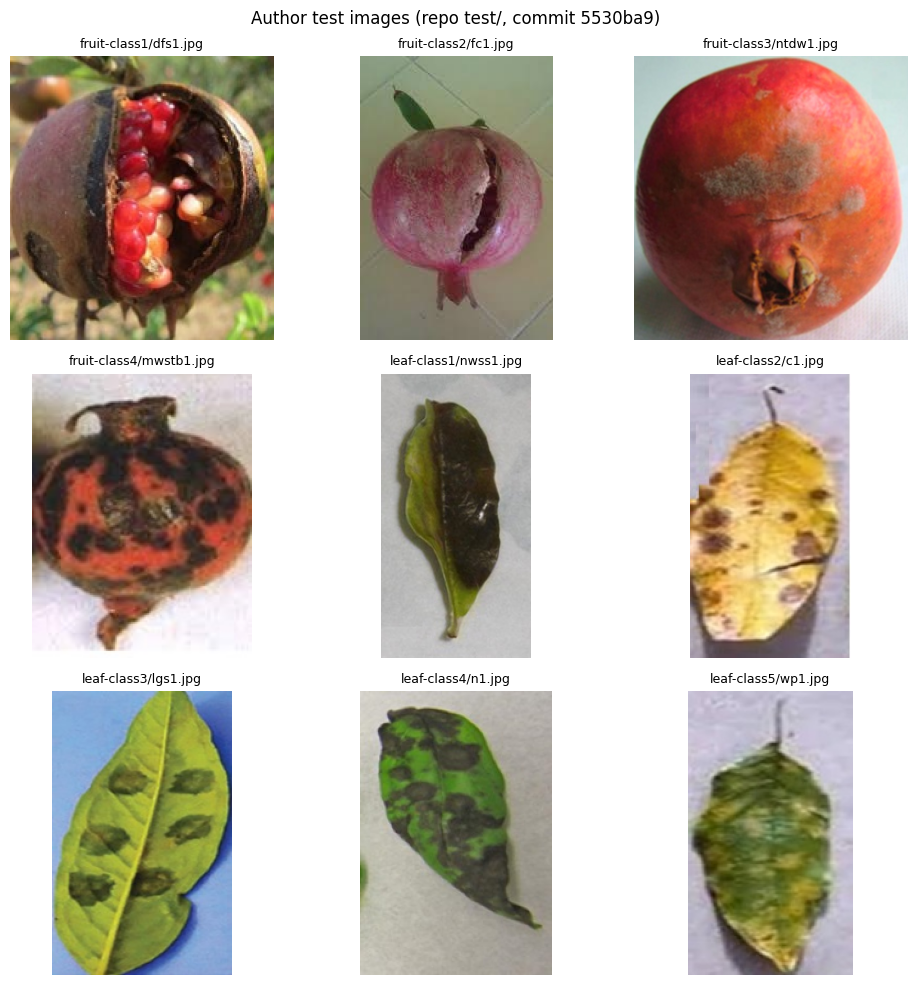

In [ ]:
import glob, os, cv2
import matplotlib.pyplot as plt
REPO_DIR = "/content/pomegranate-histo"
jpgs = sorted(glob.glob(os.path.join(REPO_DIR, "test", "*", "*.jpg")))
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for ax, p in zip(axes.ravel(), jpgs):
    img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
    rel = os.path.relpath(p, os.path.join(REPO_DIR, "test"))
    ax.imshow(img)
    ax.set_title(rel, fontsize=9)
    ax.axis("off")
fig.suptitle("Author test images (repo test/, commit 5530ba9)", fontsize=12)
fig.tight_layout()
plt.show()

## 3. Author method, ported / 著者手法の移植

Mapping from the paper's description (study flow, abstract-derived) and the pinned code `Ap_Chi_ALLFeatures.py`:

| Paper step | Author code | This notebook |
| --- | --- | --- |
| Grey image as reference (average of R,G,B) | `cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)`; zero-out pixels > 250 | verbatim |
| Normalized grey histogram, 256 bins over [0,1], zero pixels excluded | `cv2.normalize(...,0,1,NORM_MINMAX,CV_32F)`, `plt.hist(gray[gray>0],256,[0,1])` | identical binning via `np.histogram` |
| B/G/R histograms | `cv2.split` + normalize + `plt.hist(...,256,[0,1])` | identical binning; colour channels normalized to **[0,1]** (author wrote `cv2.normalize(b, 0, 256, …)` — missing `dst` argument; [0,1] is the range the script's own histogram uses) |
| Chi-Square distance, eps=1e-10 | `chi2_distance` (lines 10–17), ported **verbatim** | verbatim |
| Half-split P1/P2 distances | `np.array_split(counts, 2)` per channel | author's code split the *whole `plt.hist` return tuple* for grey (`np.array_split(axisgray, 2)`); we split the **counts array** `axisgray[0]` |

Documented adaptations (marked in code): (a) histogram counts via `np.histogram(counts, 256, range=(0,1))` — asserted equal to `plt.hist` in the walkthrough cell; (b) colour-channel normalize signature/range fixed; (c) grey half-split applied to the counts array. The author's nonzero-bin filtering (`[i for i in counts if i != 0]`) before `zip` is kept exactly, including its truncation to the shorter list.

**このセルの内容:** 著者コード `Ap_Chi_ALLFeatures.py` の `chi2_distance` をそのまま移植し、ヒストグラム計算を 3 点の文書化した修正(色チャネル正規化の範囲、`array_split` 対象、`np.histogram` の使用)を付けて実装します。

In [ ]:
import cv2
import numpy as np

def chi2_distance(histA, histB, eps=1e-10):
    # verbatim from Ap_Chi_ALLFeatures.py lines 10-17
    d = 0.5 * np.sum([((a - b) ** 2) / (a + b + eps) for (a, b) in zip(histA, histB)])
    return d

def _nz(counts):
    # keep the author's nonzero-bin filtering (zip truncates to the shorter list)
    return [i for i in counts if i != 0]

def extract_features(path):
    image = cv2.imread(path)
    img_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    img_gray[img_gray > 250] = 0                       # author preprocessing
    ngray = cv2.normalize(img_gray, None, 0, 1, cv2.NORM_MINMAX, dtype=cv2.CV_32F)
    b, g, r = cv2.split(image)
    nb = cv2.normalize(b, None, 0, 1, cv2.NORM_MINMAX, dtype=cv2.CV_32F)  # adaptation (b)
    ng = cv2.normalize(g, None, 0, 1, cv2.NORM_MINMAX, dtype=cv2.CV_32F)
    nr = cv2.normalize(r, None, 0, 1, cv2.NORM_MINMAX, dtype=cv2.CV_32F)
    hist = {  # adaptation (a): np.histogram counts == plt.hist counts for 256 bins over [0,1]
        "gray": np.histogram(ngray[ngray > 0], bins=256, range=(0, 1))[0],
        "B":    np.histogram(nb.ravel(), bins=256, range=(0, 1))[0],
        "G":    np.histogram(ng.ravel(), bins=256, range=(0, 1))[0],
        "R":    np.histogram(nr.ravel(), bins=256, range=(0, 1))[0],
    }
    feats = {
        "D_G": chi2_distance(_nz(hist["G"]), _nz(hist["gray"])),
        "D_R": chi2_distance(_nz(hist["R"]), _nz(hist["gray"])),
        "D_B": chi2_distance(_nz(hist["B"]), _nz(hist["gray"])),
        "peak_G": hist["G"].max(), "peak_R": hist["R"].max(),
        "peak_B": hist["B"].max(), "peak_gray": hist["gray"].max(),
    }
    g1, g2 = np.array_split(hist["gray"], 2)           # adaptation (c): counts array
    c1G, c2G = np.array_split(hist["G"], 2)
    c1R, c2R = np.array_split(hist["R"], 2)
    c1B, c2B = np.array_split(hist["B"], 2)
    feats["P1_D_G"] = chi2_distance(_nz(c1G), _nz(g1))
    feats["P1_D_R"] = chi2_distance(_nz(c1R), _nz(g1))
    feats["P1_D_B"] = chi2_distance(_nz(c1B), _nz(g1))
    feats["P2_D_G"] = chi2_distance(_nz(c2G), _nz(g2))
    feats["P2_D_R"] = chi2_distance(_nz(c2R), _nz(g2))
    feats["P2_D_B"] = chi2_distance(_nz(c2B), _nz(g2))
    return feats, hist

### Cell — Walkthrough on one sample (`test/fruit-class1/dfs1.jpg`)
Run the feature extraction on the first author test image and show the image with its four normalized histograms (grey computed from non-zero pixels only). Also verify adaptation (a) by asserting `np.histogram` counts equal `plt.hist` counts for this image, then print the full 13-feature vector.

**このセルの内容:** サンプル `dfs1.jpg` に対して特徴量抽出を実行し、画像と 4 種類のヒストグラムを表示。`np.histogram` と `plt.hist` のビン・カウントが一致することも検証します。

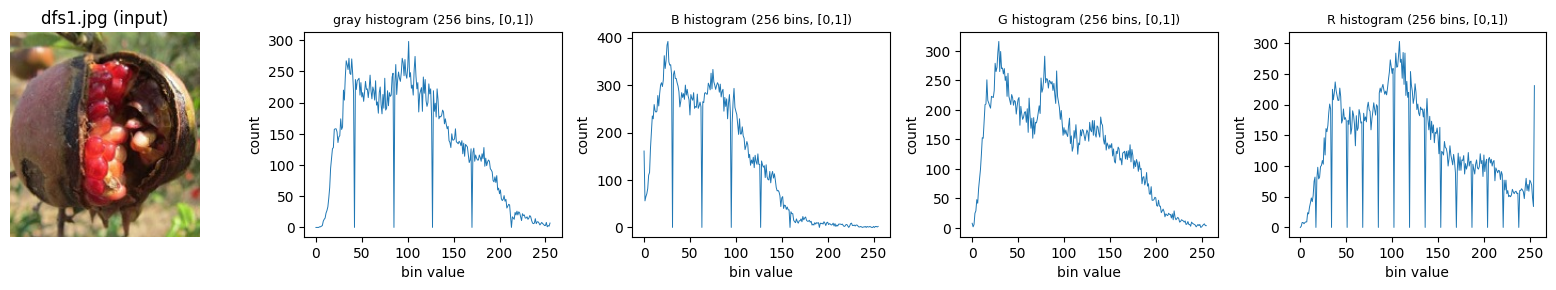

D_G       = 522.985779
D_R       = 1167.684959
D_B       = 3378.451936
peak_G    = 316.000000
peak_R    = 303.000000
peak_B    = 392.000000
peak_gray = 298.000000
P1_D_G    = 434.266318
P1_D_R    = 263.050964
P1_D_B    = 1386.696674
P2_D_G    = 79.051128
P2_D_R    = 934.183701
P2_D_B    = 2196.171767


In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
sample = "/content/pomegranate-histo/test/fruit-class1/dfs1.jpg"
img = cv2.imread(sample)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray[gray > 250] = 0
ngray = cv2.normalize(gray, None, 0, 1, cv2.NORM_MINMAX, dtype=cv2.CV_32F)
x = ngray[ngray > 0]
counts_plt, _, _ = plt.hist(x, bins=256, range=(0, 1))
plt.close()
counts_np = np.histogram(x, bins=256, range=(0, 1))[0]
assert np.array_equal(counts_plt, counts_np), "plt.hist vs np.histogram mismatch"
feats, hist = extract_features(sample)
fig, axes = plt.subplots(1, 5, figsize=(16, 3.0))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("dfs1.jpg (input)")
axes[0].axis("off")
for ax, key in zip(axes[1:], ["gray", "B", "G", "R"]):
    ax.plot(np.arange(256), hist[key], lw=0.7)
    ax.set_title(f"{key} histogram (256 bins, [0,1])", fontsize=9)
    ax.set_xlabel("bin value")
    ax.set_ylabel("count")
fig.tight_layout()
plt.show()
for k, v in feats.items():
    print(f"{k:9s} = {v:.6f}")

### Cell — Feature table for all nine test images
Apply the same extraction to every author test image and collect the 13 features per image into a DataFrame (values are Chi-Square distances and histogram peak counts, dimensionless). The table is also written to `/content/chi_features_test.csv` for inspection inside Colab.

**このセルの内容:** 9 枚すべてのテスト画像について 13 特徴量を計算し、表として表示、`/content/chi_features_test.csv` に保存します。

In [ ]:
import glob, os
import pandas as pd
REPO_DIR = "/content/pomegranate-histo"
rows = []
for p in sorted(glob.glob(os.path.join(REPO_DIR, "test", "*", "*.jpg"))):
    rel = os.path.relpath(p, os.path.join(REPO_DIR, "test"))
    feats, _ = extract_features(p)
    rows.append({"image": rel, **feats})
feat_cols = [c for c in rows[0] if c != "image"]
df = pd.DataFrame(rows)[["image"] + feat_cols]
display(df.round(4))
df.round(6).to_csv("/content/chi_features_test.csv", index=False)
print("saved /content/chi_features_test.csv  shape:", df.shape)

,image,D_G,D_R,D_B,peak_G,peak_R,peak_B,peak_gray,P1_D_G,P1_D_R,P1_D_B,P2_D_G,P2_D_R,P2_D_B
0,fruit-class1/dfs1.jpg,522.9858,1167.6850,3378.4519,316,303,392,298,434.2663,263.0510,1386.6967,79.0511,934.1837,2196.1718
1,fruit-class2/fc1.jpg,9983.5197,13731.6364,9287.0369,1360,2562,1538,1921,212.8626,3259.6896,2003.7636,8959.1485,10471.9468,11008.3427
2,fruit-class3/ntdw1.jpg,32701.4643,40143.4284,38169.1569,3629,17942,5516,2782,14755.9135,24687.5681,11693.0320,17217.6583,15554.0403,26114.9691
3,fruit-class4/mwstb1.jpg,970.8606,1107.4504,2669.3841,307,539,735,280,651.6101,447.3742,1787.4795,911.2754,1728.7016,263.6165
4,leaf-class1/nwss1.jpg,348.2409,2196.9037,12979.6480,1068,1070,1018,1061,161.5382,152.2669,2759.4633,566.8737,2044.6368,6287.4220
5,leaf-class2/c1.jpg,200.1062,2804.5624,5177.5761,528,529,325,514,62.7088,332.3103,638.0570,3716.4818,2550.4808,2183.4100
6,leaf-class3/lgs1.jpg,5410.6106,4081.7513,18427.4423,1143,892,1402,1313,122.7958,211.3139,6991.9730,655.0416,4287.2213,10713.3150
7,leaf-class4/n1.jpg,750.5072,1184.3560,4560.4838,530,582,586,541,308.7957,867.0740,1587.1673,469.3826,82.0555,570.4991
8,leaf-class5/wp1.jpg,598.6787,720.3038,6643.8986,532,510,451,517,292.1341,135.8693,1550.3656,471.3145,2555.2978,5443.3505


saved /content/chi_features_test.csv  shape: (9, 14)


### Cell — Result graph (additional visualization created for this notebook)
Bar chart of the three full-histogram Chi-Square distances (D-G, D-R, D-B) per test image. **This graph is an additional visualization created for this notebook — not a figure from the paper.**

**このセルの内容:** 各テスト画像のカイ二乗距離(D-G/D-R/D-B)を棒グラフにした、本ノートブック独自の追加可視化です(論文の図ではありません)。

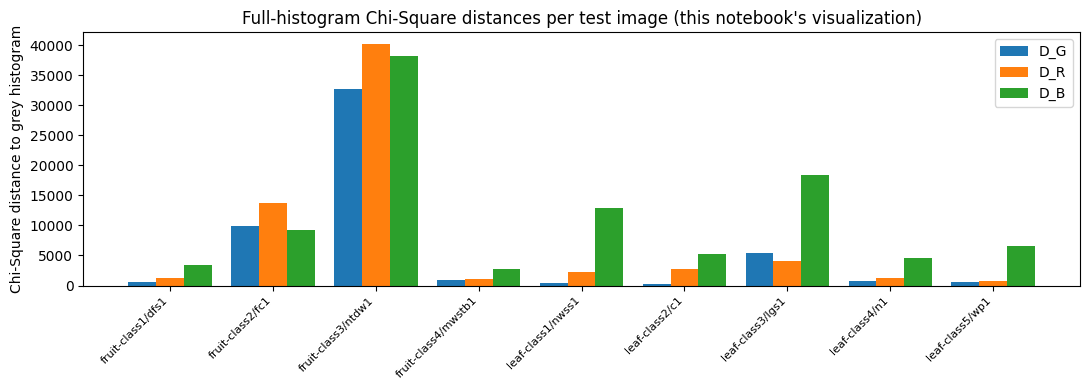

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
labels = df["image"].str.replace(".jpg", "", regex=False)
x = np.arange(len(df))
w = 0.27
fig, ax = plt.subplots(figsize=(11, 4))
for i, col in enumerate(["D_G", "D_R", "D_B"]):
    ax.bar(x + (i - 1) * w, df[col], width=w, label=col)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Chi-Square distance to grey histogram")
ax.set_title("Full-histogram Chi-Square distances per test image (this notebook's visualization)")
ax.legend()
fig.tight_layout()
plt.show()

### Cell — Open the author supplement (`features of Histo.xlsx`)
The paper-linked supplement (root of the pinned repository) is a workbook of histogram features. We list its sheets, shapes and first rows so the feature layout can be compared with this notebook's computation.

**このセルの内容:** 著者の補足ワークブック `features of Histo.xlsx` のシート・列・先頭行を表示します。

In [ ]:
import pandas as pd
xl = pd.ExcelFile("/content/pomegranate-histo/features of Histo.xlsx")
print("sheets:", xl.sheet_names)
for sh in xl.sheet_names:
    d = xl.parse(sh)
    print(f"--- sheet {sh!r}: shape {d.shape}; columns: {list(d.columns)[:16]}")
    display(d.head(8))

sheets: ['Sheet1', 'Copy of Sheet1', 'Sheet2']
--- sheet 'Sheet1': shape (12, 11); columns: ['sr', 'feature', 'Fruit class 1', 'Fruit class 2', 'Fruit class 3', 'Fruit class 4', 'Leaf class-1', 'Leaf class-2', 'Leaf class-3', 'Leaf class-4', 'Leaf class-5']


,sr,feature,Fruit class 1,Fruit class 2,Fruit class 3,Fruit class 4,Leaf class-1,Leaf class-2,Leaf class-3,Leaf class-4,Leaf class-5
0,1.0,D-G,271.526558,217.571219,30781.421104,370.842054,237.881819,34.219707,109.079857,205.612962,220.307971
1,2.0,D-R,279.497118,1170.681096,38877.864331,328.309948,205.979692,202.247750,169.989648,452.672975,74.394774
2,3.0,D-B,1118.886101,774.192134,39945.507867,1133.412136,2765.889528,603.563308,6705.527642,1567.410554,1523.676649
3,NaN,peak-G,316.000000,340.000000,6968.000000,236.000000,488.000000,108.000000,139.000000,311.000000,140.000000
4,NaN,peak-R,237.000000,293.000000,17942.000000,110.000000,362.000000,97.000000,144.000000,411.000000,208.000000
5,NaN,peak-B,392.000000,331.000000,5516.000000,290.000000,637.000000,118.000000,1402.000000,521.000000,203.000000
6,NaN,P1- D-G,234.497572,180.427100,17750.409097,209.518203,129.099738,3.347186,23.250807,13.930551,13.918428
7,NaN,P1- D-R,190.404298,66.512056,17191.691199,181.526178,140.866301,0.666667,139.841960,3.892103,5.868998


--- sheet 'Copy of Sheet1': shape (12, 11); columns: ['sr', 'feature', 'Fruit class 1', 'Fruit class 2', 'Fruit class 3', 'Fruit class 4', 'Leaf class-1', 'Leaf class-2', 'Leaf class-3', 'Leaf class-4', 'Leaf class-5']


,sr,feature,Fruit class 1,Fruit class 2,Fruit class 3,Fruit class 4,Leaf class-1,Leaf class-2,Leaf class-3,Leaf class-4,Leaf class-5
0,1.0,D-G,271.526558,217.571219,30781.421104,370.842054,237.881819,34.219707,109.079857,205.612962,220.307971
1,2.0,D-R,279.497118,1170.681096,38877.864331,328.309948,205.979692,202.247750,169.989648,452.672975,74.394774
2,3.0,D-B,1118.886101,774.192134,39945.507867,1133.412136,2765.889528,603.563308,6705.527642,1567.410554,1523.676649
3,NaN,peak-G,316.000000,340.000000,6968.000000,236.000000,488.000000,108.000000,139.000000,311.000000,140.000000
4,NaN,peak-R,237.000000,293.000000,17942.000000,110.000000,362.000000,97.000000,144.000000,411.000000,208.000000
5,NaN,peak-B,392.000000,331.000000,5516.000000,290.000000,637.000000,118.000000,1402.000000,521.000000,203.000000
6,NaN,P1- D-G,234.497572,180.427100,17750.409097,209.518203,129.099738,3.347186,23.250807,13.930551,13.918428
7,NaN,P1- D-R,190.404298,66.512056,17191.691199,181.526178,140.866301,0.666667,139.841960,3.892103,5.868998


--- sheet 'Sheet2': shape (6, 11); columns: ['sr', 'feature', 'Fruit class 1', 'Fruit class 2', 'Fruit class 3', 'Fruit class 4', 'Leaf class-1', 'Leaf class-2', 'Leaf class-3', 'Leaf class-4', 'Leaf class-5']


,sr,feature,Fruit class 1,Fruit class 2,Fruit class 3,Fruit class 4,Leaf class-1,Leaf class-2,Leaf class-3,Leaf class-4,Leaf class-5
0,1,D-G,271.526558,217.571219,30781.421104,370.842054,237.881819,34.219707,109.079857,205.612962,220.307971
1,2,D-R,279.497118,1170.681096,38877.864331,328.309948,205.979692,202.247750,169.989648,452.672975,74.394774
2,3,D-B,1118.886101,774.192134,39945.507867,1133.412136,2765.889528,603.563308,6705.527642,1567.410554,1523.676649
3,4,D-G,377.301993,82064.326447,310.736689,502.155005,737.118939,127.637429,56.470397,234.072862,69.311628
4,5,D-R,469.385958,85653.352338,1651.800969,690.506858,198.156410,193.562815,88.960079,286.352784,: 55.84911756347901
5,6,D-B,812.751584,80716.592694,5864.376205,1667.077680,2897.622771,537.198457,12202.333513,2087.698447,330.533181


### Cell — Supplement vs recomputation (per class)
`Sheet1` stores one **12-feature row per class column** (`D-G, D-R, D-B, peak-G/R/B, P1-/P2- D-G/R/B`) — the same layout as the author's `Ann2b.py` 12-value feature vector. We aggregate this notebook's per-image features by test folder and compare class-wise against the author's stored values (case-insensitive name/column matching). The supplement does not document which images (train or test) produced its values, so this is a **plausibility check of the feature layout and magnitudes, not an equivalence claim**; differing values are reported as-is.

**このセルの内容:** 本ノートブックの特徴量をテスト・フォルダ(クラス)ごとに集約し、著者の補足ワークブックのクラス列と比較します。補足資料はどの画像から計算されたかを記載していないため、これはレイアウトと桁の整合確認であり、一致の主張ではありません。

In [ ]:
import re
import numpy as np
import pandas as pd
xl = pd.ExcelFile("/content/pomegranate-histo/features of Histo.xlsx")
d = xl.parse("Sheet1")
def norm(s):
    return re.sub(r"[\s\-_/]", "", str(s)).lower()
def author_column(folder):
    m = re.search(r"(fruit|leaf)[\s\-]*class[\s\-]*(\d+)", folder, re.I)
    return (f"Fruit class {m.group(2)}" if m.group(1).lower() == "fruit"
            else f"Leaf class-{m.group(2)}")
df["class"] = df["image"].str.split("/").str[0]
means = df.groupby("class")[feat_cols].mean()
SUBSET = ["D_G", "D_R", "D_B", "peak_G", "peak_R", "peak_B",
          "P1_D_G", "P1_D_R", "P1_D_B", "P2_D_G", "P2_D_R", "P2_D_B"]
rows = []
for cls in means.index:
    col = author_column(cls)
    col_match = next((c for c in d.columns if norm(c) == norm(col)), None)
    if col_match is None:
        print(f"no supplement column for {cls}")
        continue
    for k in SUBSET:
        knorm = norm(k)
        arow = d.loc[d["feature"].map(norm) == knorm]
        if arow.empty:
            continue
        a = pd.to_numeric(arow.iloc[0][col_match], errors="coerce")
        if pd.isna(a):
            continue
        rows.append({"class": cls, "feature": k,
                     "author_supplement": float(a),
                     "notebook_test_mean": float(means.loc[cls, k]),
                     "abs_diff": abs(float(a) - float(means.loc[cls, k]))})
cmp_df = pd.DataFrame(rows)
display(cmp_df.round(3))
print("compared", len(cmp_df), "author feature/class pairs; "
      "layout/magnitude check only (supplement provenance undocumented).")

,class,feature,author_supplement,notebook_test_mean,abs_diff
0,fruit-class1,D_G,271.527,522.986,251.459
1,fruit-class1,D_R,279.497,1167.685,888.188
2,fruit-class1,D_B,1118.886,3378.452,2259.566
3,fruit-class1,peak_G,316.000,316.000,0.000
4,fruit-class1,peak_R,237.000,303.000,66.000
...,...,...,...,...,...
103,leaf-class5,P1_D_R,5.869,135.869,130.000
104,leaf-class5,P1_D_B,1210.451,1550.366,339.914
105,leaf-class5,P2_D_G,1471.947,471.314,1000.632
106,leaf-class5,P2_D_R,2242.443,2555.298,312.855


compared 108 author feature/class pairs; layout/magnitude check only (supplement provenance undocumented).


## 4. Interpretation and limitations / 解釈と限界

The executed example computes exactly the feature family the paper proposes — grey-referenced Chi-Square distances over R/G/B histograms, full and half-split — on the author's own test images, so the values above are a faithful *feature-extraction* result. This **does not** verify the paper's dataset-level classification accuracies: the ANN/CNN stage is out of scope (no trained weights exist in the repository, and its Keras scripts follow a different raw-image design), no class labels are needed or used here, and folder names (`fruit-class1`…) are shown without disease-name interpretation. The author's `Ann2b.py` confirms the downstream ANN consumed a 12-value feature row, matching the subset shown in the comparison cell.

**解釈と限界:** 上記の値は著者コードに基づく特徴量抽出の忠実な結果です。ただし分類段階(ANN)は重みがないため未検証であり、データセット全体の精度再現ではありません。クラス名も解釈していません。

### References / 参考文献
- Paper: DOI [10.1049/cit2.12390](https://doi.org/10.1049/cit2.12390) — CAAI Transactions on Intelligence Technology 10(2):317–336 (2024), CC BY 4.0.
- Author code: `prajwalkumarprof/Domain-Independent-Adaptive-Histogram-Based-Approach-` @ `5530ba9cd22b383d95ad5417b4b2a67a51f642ad`, file `Ap_Chi_ALLFeatures.py` (`chi2_distance` ported verbatim; three documented adaptations).
- Data: author test images `test/` and supplement `features of Histo.xlsx` from the same pinned commit (retrieved inside this notebook; no other data used).
- PhenoPaper investigation `p-ebae12f1eb1e37fc5316ed57eba1723e-20261007T193845Z-249288` was used as prior research guidance only; primary evidence here is the pinned code itself.